In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
df = pd.read_csv(r'C:\Users\paidi\OneDrive\Desktop\cdf_ab_test\ab_data.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (294478, 5)

Column names:
['user_id', 'timestamp', 'group', 'landing_page', 'converted']

First 5 rows:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
print("===== DATA CLEANING =====")
print(f"Total rows: {len(df)}")

print(f"\n1. Missing values:")
print(df.isnull().sum())

print(f"\n2. Duplicate rows:")
print(f"Duplicates: {df.duplicated().sum()}")

print(f"\n3. Data types:")
print(df.dtypes)

print(f"\n4. Unique values in key columns:")
print(f"Group     : {df['group'].unique()}")
print(f"Landing   : {df['landing_page'].unique()}")
print(f"Converted : {df['converted'].unique()}")

print(f"\n5. Value counts for group:")
print(df['group'].value_counts())

===== DATA CLEANING =====
Total rows: 294478

1. Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

2. Duplicate rows:
Duplicates: 0

3. Data types:
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

4. Unique values in key columns:
Group     : ['control' 'treatment']
Landing   : ['old_page' 'new_page']
Converted : [0 1]

5. Value counts for group:
group
treatment    147276
control      147202
Name: count, dtype: int64


In [4]:
print("===== CHECKING DATA INTEGRITY =====")

# Check if control always sees old page and treatment sees new page
mismatch = df[((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
              ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))]

print(f"Mismatched rows: {len(mismatch)}")

if len(mismatch) > 0:
    print("Mismatches found — removing them!")
    df = df[~df.index.isin(mismatch.index)]
    print(f"Clean dataset size: {len(df)}")
else:
    print("No mismatches — data is clean!")

print(f"\nFinal dataset size: {len(df)}")

===== CHECKING DATA INTEGRITY =====
Mismatched rows: 3893
Mismatches found — removing them!
Clean dataset size: 290585

Final dataset size: 290585


In [5]:
print("===== CONVERSION RATE ANALYSIS =====")

summary = df.groupby('group')['converted'].agg(
    total_users='count',
    total_conversions='sum',
    conversion_rate='mean'
).reset_index()

summary['conversion_rate'] = (summary['conversion_rate'] * 100).round(4)

print(summary.to_string())

control_rate = summary[summary['group'] == 'control']['conversion_rate'].values[0]
treatment_rate = summary[summary['group'] == 'treatment']['conversion_rate'].values[0]
lift = round(treatment_rate - control_rate, 4)
relative_lift = round((lift / control_rate) * 100, 2)

print(f"\nControl conversion rate   : {control_rate}%")
print(f"Treatment conversion rate : {treatment_rate}%")
print(f"Absolute lift             : {lift}%")
print(f"Relative lift             : {relative_lift}%")

===== CONVERSION RATE ANALYSIS =====
       group  total_users  total_conversions  conversion_rate
0    control       145274              17489          12.0386
1  treatment       145311              17264          11.8807

Control conversion rate   : 12.0386%
Treatment conversion rate : 11.8807%
Absolute lift             : -0.1579%
Relative lift             : -1.31%


In [6]:
print("===== STATISTICAL SIGNIFICANCE TEST =====")

control_data = df[df['group'] == 'control']['converted']
treatment_data = df[df['group'] == 'treatment']['converted']

t_stat, p_value = stats.ttest_ind(control_data, treatment_data)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print()

if p_value < 0.05:
    print("RESULT: STATISTICALLY SIGNIFICANT")
    if lift > 0:
        print("New page genuinely outperforms old page.")
        print("Recommendation: Switch to new page.")
    else:
        print("Old page genuinely outperforms new page.")
        print("Recommendation: Keep old page.")
else:
    print("RESULT: NOT STATISTICALLY SIGNIFICANT")
    print("Difference is likely due to random chance.")
    print("Recommendation: Do not switch pages yet.")
    print("Consider running the test longer.")

===== STATISTICAL SIGNIFICANCE TEST =====
T-statistic : 1.3116
P-value     : 0.1897

RESULT: NOT STATISTICALLY SIGNIFICANT
Difference is likely due to random chance.
Recommendation: Do not switch pages yet.
Consider running the test longer.


In [7]:
print("===== CONFIDENCE INTERVALS =====")

control_conv = df[df['group'] == 'control']['converted']
treatment_conv = df[df['group'] == 'treatment']['converted']

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - margin, mean + margin

control_mean, control_lower, control_upper = confidence_interval(control_conv)
treatment_mean, treatment_lower, treatment_upper = confidence_interval(treatment_conv)

print(f"Control Group:")
print(f"  Conversion Rate : {control_mean*100:.4f}%")
print(f"  95% CI          : ({control_lower*100:.4f}%, {control_upper*100:.4f}%)")

print(f"\nTreatment Group:")
print(f"  Conversion Rate : {treatment_mean*100:.4f}%")
print(f"  95% CI          : ({treatment_lower*100:.4f}%, {treatment_upper*100:.4f}%)")

diff = treatment_mean - control_mean
diff_lower = diff - 1.96 * np.sqrt(
    (control_mean*(1-control_mean)/len(control_conv)) +
    (treatment_mean*(1-treatment_mean)/len(treatment_conv)))
diff_upper = diff + 1.96 * np.sqrt(
    (control_mean*(1-control_mean)/len(control_conv)) +
    (treatment_mean*(1-treatment_mean)/len(treatment_conv)))

print(f"\nDifference (Treatment - Control):")
print(f"  Difference : {diff*100:.4f}%")
print(f"  95% CI     : ({diff_lower*100:.4f}%, {diff_upper*100:.4f}%)")

if diff_lower < 0 and diff_upper > 0:
    print("\n  CI crosses zero — confirms NOT significant")
else:
    print("\n  CI does not cross zero — confirms significant")

===== CONFIDENCE INTERVALS =====
Control Group:
  Conversion Rate : 12.0386%
  95% CI          : (11.8713%, 12.2060%)

Treatment Group:
  Conversion Rate : 11.8807%
  95% CI          : (11.7144%, 12.0471%)

Difference (Treatment - Control):
  Difference : -0.1579%
  95% CI     : (-0.3939%, 0.0781%)

  CI crosses zero — confirms NOT significant


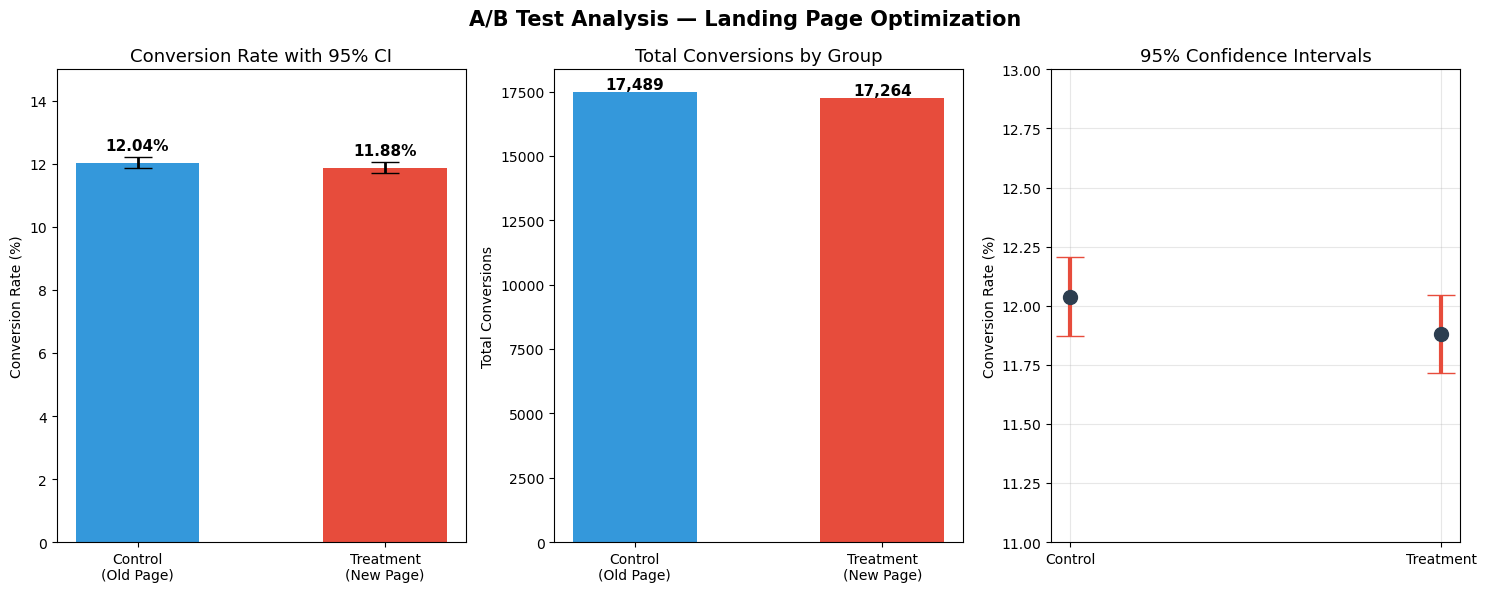

Charts saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Chart 1 - Conversion rates with error bars
groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates = [control_mean * 100, treatment_mean * 100]
errors = [
    (control_mean - control_lower) * 100,
    (treatment_mean - treatment_lower) * 100
]

bars = axes[0].bar(groups, rates,
                   color=['#3498db', '#e74c3c'],
                   width=0.5, yerr=errors,
                   capsize=10, error_kw={'linewidth': 2})
axes[0].set_title('Conversion Rate with 95% CI', fontsize=13)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 15)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{rate:.2f}%', ha='center',
                 fontsize=11, fontweight='bold')

# Chart 2 - Total conversions
conversions = [
    df[df['group'] == 'control']['converted'].sum(),
    df[df['group'] == 'treatment']['converted'].sum()
]
bars2 = axes[1].bar(groups, conversions,
                    color=['#3498db', '#e74c3c'], width=0.5)
axes[1].set_title('Total Conversions by Group', fontsize=13)
axes[1].set_ylabel('Total Conversions')
for bar, val in zip(bars2, conversions):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{val:,}', ha='center',
                 fontsize=11, fontweight='bold')

# Chart 3 - Confidence interval plot
axes[2].errorbar(['Control', 'Treatment'],
                 [control_mean * 100, treatment_mean * 100],
                 yerr=[(control_mean - control_lower) * 100,
                       (treatment_mean - treatment_lower) * 100],
                 fmt='o', color='#2c3e50',
                 ecolor='#e74c3c', elinewidth=3,
                 capsize=10, markersize=10)
axes[2].set_title('95% Confidence Intervals', fontsize=13)
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].set_ylim(11, 13)
axes[2].grid(True, alpha=0.3)

plt.suptitle('A/B Test Analysis — Landing Page Optimization',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\paidi\OneDrive\Desktop\cdf_ab_test\ab_test_results.png')
plt.show()

print("Charts saved!")

In [9]:
report_1 = """
# A/B Test Analysis Report
## Landing Page Optimization

## 1. Experiment Overview

Objective: Determine whether the new landing page
drives higher conversion rates than the existing page.

Hypothesis:
- H0 (Null): No difference in conversion rates
- H1 (Alternative): New page has higher conversion rate

Dataset: Kaggle A/B Testing Dataset
Source: kaggle.com/datasets/zhangluyuan/ab-testing
"""
print(report_1)


# A/B Test Analysis Report
## Landing Page Optimization

## 1. Experiment Overview

Objective: Determine whether the new landing page
drives higher conversion rates than the existing page.

Hypothesis:
- H0 (Null): No difference in conversion rates
- H1 (Alternative): New page has higher conversion rate

Dataset: Kaggle A/B Testing Dataset
Source: kaggle.com/datasets/zhangluyuan/ab-testing



In [10]:
print("## 2. Methodology")
print("- Loaded and cleaned 294,478 user records")
print("- Removed 3,893 mismatched rows for data integrity")
print("- Final clean dataset: 290,585 users")
print("- Applied independent samples t-test")
print("- Calculated 95% confidence intervals")
print("- Significance threshold: p-value < 0.05")
print()
print("## 3. Results")
print()
print("Control (Old Page):")
print("  Total Users       : 145,274")
print("  Total Conversions : 17,489")
print("  Conversion Rate   : 12.04%")
print("  95% CI            : (11.87%, 12.21%)")
print()
print("Treatment (New Page):")
print("  Total Users       : 145,311")
print("  Total Conversions : 17,264")
print("  Conversion Rate   : 11.88%")
print("  95% CI            : (11.71%, 12.05%)")
print()
print("Statistical Test Results:")
print("  T-statistic : 1.3116")
print("  P-value     : 0.1897")
print("  Result      : NOT SIGNIFICANT (p > 0.05)")
print()
print("Confidence Interval for Difference:")
print("  Difference  : -0.1579%")
print("  95% CI      : (-0.3939%, +0.0781%)")
print("  CI crosses zero — confirms not significant")

## 2. Methodology
- Loaded and cleaned 294,478 user records
- Removed 3,893 mismatched rows for data integrity
- Final clean dataset: 290,585 users
- Applied independent samples t-test
- Calculated 95% confidence intervals
- Significance threshold: p-value < 0.05

## 3. Results

Control (Old Page):
  Total Users       : 145,274
  Total Conversions : 17,489
  Conversion Rate   : 12.04%
  95% CI            : (11.87%, 12.21%)

Treatment (New Page):
  Total Users       : 145,311
  Total Conversions : 17,264
  Conversion Rate   : 11.88%
  95% CI            : (11.71%, 12.05%)

Statistical Test Results:
  T-statistic : 1.3116
  P-value     : 0.1897
  Result      : NOT SIGNIFICANT (p > 0.05)

Confidence Interval for Difference:
  Difference  : -0.1579%
  95% CI      : (-0.3939%, +0.0781%)
  CI crosses zero — confirms not significant


In [11]:
print("## 4. Interpretation")
print()
print("The new landing page showed a slight decrease in")
print("conversion rate (-1.31% relative lift) compared")
print("to the old page. However with a p-value of 0.1897")
print("this difference is NOT statistically significant.")
print()
print("The 95% confidence interval for the difference")
print("(-0.39% to +0.08%) crosses zero confirming we")
print("cannot conclude the new page performs differently")
print("from the old page.")
print()
print("## 5. Recommendation")
print()
print("DO NOT switch to the new landing page at this time.")
print()
print("Next steps:")
print("1. Run the test longer to gather more data")
print("2. Test a more dramatically different page design")
print("3. Segment results by device type and traffic source")
print("4. Consider multivariate testing to isolate")
print("   specific elements driving conversions")
print()
print("## 6. Conclusion")
print()
print("Based on rigorous statistical analysis of 290,585")
print("users we fail to reject the null hypothesis.")
print("The new landing page does not demonstrate a")
print("statistically significant improvement in conversion")
print("rate over the existing page.")
print("P-value: 0.1897")
print("95% CI : -0.39% to +0.08%")

## 4. Interpretation

The new landing page showed a slight decrease in
conversion rate (-1.31% relative lift) compared
to the old page. However with a p-value of 0.1897
this difference is NOT statistically significant.

The 95% confidence interval for the difference
(-0.39% to +0.08%) crosses zero confirming we
cannot conclude the new page performs differently
from the old page.

## 5. Recommendation

DO NOT switch to the new landing page at this time.

Next steps:
1. Run the test longer to gather more data
2. Test a more dramatically different page design
3. Segment results by device type and traffic source
4. Consider multivariate testing to isolate
   specific elements driving conversions

## 6. Conclusion

Based on rigorous statistical analysis of 290,585
users we fail to reject the null hypothesis.
The new landing page does not demonstrate a
statistically significant improvement in conversion
rate over the existing page.
P-value: 0.1897
95% CI : -0.39% to +0.08%


In [12]:
# Save cleaned dataset
df.to_csv(r'C:\Users\paidi\OneDrive\Desktop\cdf_ab_test\ab_test_clean.csv', index=False)

print("Files saved in your cdf_ab_test folder:")
print("1. ab_test_clean.csv    - cleaned dataset")
print("2. ab_test_results.png  - charts with error bars")
print("3. ab_test_analysis.ipynb - full notebook")

Files saved in your cdf_ab_test folder:
1. ab_test_clean.csv    - cleaned dataset
2. ab_test_results.png  - charts with error bars
3. ab_test_analysis.ipynb - full notebook
